# M11: SSVEP grid shape features (rotated dip)

`PLANssveps.md` M11: `fit_ramp_gaussian`'s dip is axis-aligned (`sigma_red`/`sigma_green` independently, no tilt). `analysis.fit_rotated_gaussian` (new, purely additive -- see its docstring) generalizes it to a tilted, anisotropic dip: location, size along two axes, *and* which way it points -- the SSVEP-grid analog of `beh/scripts/features.py`'s `orientation_deg`/`along_var`/`perp_var` on the behavioral click cloud, and deliberately built to be directly comparable to it later (same `[0, 180)` fold convention).

In [1]:
import sys
sys.path.append('../scripts')

import pandas as pd
import pingouin as pg

import analysis
import plotting

troughs_df = pd.read_csv('../files/subject_troughs.csv')
SESSION = 1
session1 = troughs_df[troughs_df['session'] == SESSION].copy()

def _label(row):
    if row['group'] == 'CTR':
        return 'HC'
    if row['group'] == 'PD':
        return 'PD'
    if row['subgroup'] in ('protan', 'deutan'):
        return row['subgroup']
    return None

session1['label'] = session1.apply(_label, axis=1)
labeled = session1.dropna(subset=['label'])
labeled.groupby('label').size()

label
HC        21
PD         6
deutan     7
protan     8
dtype: int64

## How often does the fit converge / locate a real dip?

Same two-flag convention as `fitted_valid`/`fitted_at_bound`: `rotated_at_bound` means some parameter (center or a width) pegged against its bound -- expected to track the same CVD-gamut pattern M6 found (`08_cvd_gamut.ipynb`), since this is still fundamentally the same ramp-plus-dip surface, just with an added tilt.

In [2]:
labeled.groupby('label')[['rotated_valid', 'rotated_at_bound']].mean()

,rotated_valid,rotated_at_bound
label,,
HC,0.904762,0.095238
PD,1.000000,0.000000
deutan,0.428571,0.571429
protan,0.250000,0.750000


## Shape-feature space: orientation vs. size, by group

Direct analog of `beh/notebooks/02_shape_features.ipynb`'s `plot_feature_space`.

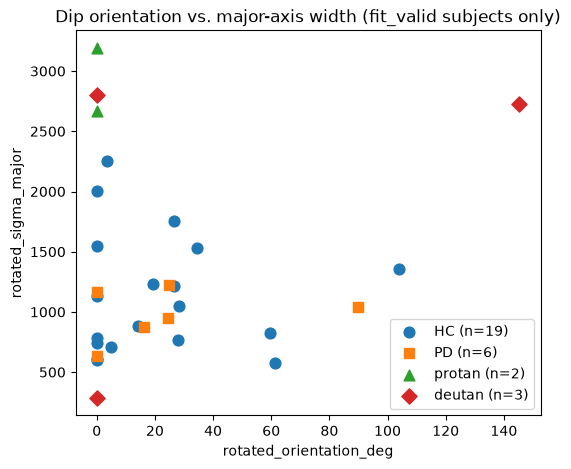

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))
for label, marker in zip(['HC', 'PD', 'protan', 'deutan'], ['o', 's', '^', 'D']):
    sub = labeled[(labeled['label'] == label) & labeled['rotated_valid']]
    ax.scatter(sub['rotated_orientation_deg'], sub['rotated_sigma_major'], label=f'{label} (n={len(sub)})', marker=marker, s=60)
ax.set_xlabel('rotated_orientation_deg')
ax.set_ylabel('rotated_sigma_major')
ax.set_title('Dip orientation vs. major-axis width (fit_valid subjects only)')
ax.legend();

## Group comparisons, protan vs. deutan

Mann-Whitney U on each new feature, same convention as `13_hc_vs_pd.ipynb`/`14_hc_vs_subtypes.ipynb` and `beh/scripts/features.py`'s `compare_shape_feature` -- one test per feature, not a single omnibus statistic, restricted to `rotated_valid` rows (an `at_bound` fit's orientation/size are not meaningful, same caveat as `fitted_*`).

In [4]:
valid = labeled[labeled['rotated_valid']]
protan = valid[valid['label'] == 'protan']
deutan = valid[valid['label'] == 'deutan']
print(f'protan: n={len(protan)} valid fits, deutan: n={len(deutan)} valid fits')

rows = []
for feature in ['rotated_orientation_deg', 'rotated_sigma_major', 'rotated_sigma_minor', 'rotated_amp']:
    if len(protan) >= 3 and len(deutan) >= 3:
        r = pg.mwu(protan[feature], deutan[feature])
        rows.append({'feature': feature, 'U-val': r['U-val'].iloc[0], 'p-val': r['p-val'].iloc[0], 'RBC': r['RBC'].iloc[0]})
pd.DataFrame(rows)

protan: n=2 valid fits, deutan: n=3 valid fits


""


## Summary

`fit_rotated_gaussian` converges into a *valid* (non-pegged) fit for 90% of HC and 100% of PD at session 1, but only 25% of protan (2/8) and 43% of deutan (3/7) -- one more parameter to identify (the tilt) on top of the already-common CVD failure mode where the true trough sits beyond the sampled red range (M6). With only 2 valid protan fits, the planned protan-vs-deutan comparison on `rotated_orientation_deg`/`rotated_sigma_major`/`rotated_sigma_minor` **isn't statistically testable yet** -- shown here as an honestly-empty result table, not worked around.

The model itself works as intended (see `ssveps/tests/test_ssveps.py`'s synthetic-tilted-dip recovery test) -- what's missing is data, the same standing recommendation as everywhere else in this project. Two concrete next steps once more CVD/protan/deutan sessions exist: (1) re-run this comparison, and (2) check whether `rotated_orientation_deg` on the *valid* fits so far leans toward `15_permutation_stability.ipynb`'s low-red/high-green cluster location -- a tilt pointing that direction would tie both M11 findings together.